# Spontaneous Raman Spectra Pipeline Template

below listed out all the helper functions wrote

1. from helpers import save_and_load
    1. save_spectrum(fileType: 'txt' or 'csv', outputpath as Path variable, wavenumber as nparray, intensity as nparray, [optional] background curve as nparray, header defaults to False means no header) -> None:
        saves the wavenumber and intensity data to a file either csv or txt format
    2. read_spectrum(path as Path variable, header defaults to False) -> Tuple[np.ndarry]
        read a spectrum file, the first coln will be wavenumber, second coln will be intensity, [optional] third coln will be background
    3. save_ratios(path as Path variable, data as a List of Dict[str, any], header defaults to true) -> None:
        saves a list of dictionaries containing ratio data to a csv file
    4. load_ratios(path as Path variable) -> pd.DataFrame:
        loads ratio data from a csv or a txt file into a pandas DataFrame
2. from helpers import preprocessing
    1. fitted_bg_subtraction(wavenumber as nparray, intensity as nparray, range start defaults to 1000, range end defaults to 3900) -> Tuple[nparray, nparray, nparry]:
        performs a background subtraction by fitting a Gaussian curve to the wavenumber range from (range_start to range_end), saves the fitted Gaussia curve to the third nparray. This function only fits to one Gaussian peak
    2. spectra_bg_subtraction(wavenumber as nparray, intensity as nparray, background spectra wavenumber as nparray, background spectra intensity sa nparray) -> Tuple[nparray, nparray]:
        performs a background subtraction if you provide a background spectra, no background fitting
    3. simple_baseline_correction(wavenumber as nparray, intensity as nparray, cell_silent_start as int, cell_silent_end as int, trim defaults to None, min_max defaults to True) -> Tuple[nparray, nparray]:
        performs a simple baseline correction on a Raman spectrum by setting the average intensity value from 2300 to 2600 as zero, everything below will be set to zero. min_max True if perform a min-max normalization
    4. polynomial_baseline_correction(wavenumber as nparray, intensity as nparray) -> Tuple[nparray, nparray]:
        performs a baseline correction by fitting a polynomial to the spectrum
    5. smoothing(wavenumber as nparray, intensity as nparray, window_length as int defaults to 11, polyorder as int defaults to 2) -> Tuple[nparray, nparray]:
        performs a savitzky-golay filter for a spectrum to smooth
3. from helpers import analysis
    1. peak_ratio_calculator(wavenumber as nparray, intensity as nparray, peak 1 location, peak 2 location, [optional] background intensity) -> float:
        calculate a ratio between the intensity at two peak wavenumber location. If a background intensity is provided, peak 2 will be seen as a water background
    2. area_under_curve_ratio_calculator(wavenumber as nparry, intensity as nparray, peak range 1, peak range 2, [optional] background intensity) -> float:
        calculate the area underr the curve for a specified range of wavenumber in a Raman spectrum. If a background intensity is provided, peak 2's intensity will be read from background intensity
    3. t_test_calculator(group_1 as nparray, group_2 as nparray) -> tuple:
        performs a t-test between two groups of data
4. from helpers import plots
    
    nparray is able to used by matplotlib, for all this part, please see the script yourself since might be a bit complicate to explain here.

### Library Loading

In [121]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

os.chdir(os.getcwd())

from helpers import save_and_load as sl
from helpers import preprocessing as prep
from helpers import analysis
from helpers import plots
import pathlib as Path

# Reload helper modules so an already-running Jupyter kernel picks up file edits.
import importlib
importlib.reload(sl)
importlib.reload(prep)
importlib.reload(analysis)
importlib.reload(plots)


<module 'helpers.plots' from 'd:\\Chrome\\Workspace\\Labs\\Shi\\spontaneous\\helpers\\plots.py'>

Load file path to a df table

In [122]:
base_dir = r'D:\Chrome\Workspace\Projects\Rapamycin\data\spontaneous\Rapamycin_2'
target_organ = "Gut"
base_dir = Path.Path(base_dir)
all_files = sorted(base_dir.glob("*/*/*/*.txt"))
rows = []

for path in all_files:
    rel = path.relative_to(base_dir)
    day, organ, group, filename = rel.parts
    if organ != target_organ:
        continue

    name_lower = path.name.lower()
    if ("fitted" in name_lower or "baseline" in name_lower or "bg" in name_lower or "background" in name_lower):
        continue
    
    if ("ctrl" not in name_lower and "rapa" not in name_lower):
        continue

    bg_path = path.with_name(path.stem + '_BG.txt')
    if not bg_path.exists():
        print(f"Warning: Background file {bg_path} does not exist for {path}")
        continue
    
    rows.append({
        'day': day.split('_')[1],
        'organ': organ,
        'group': group,
        'filename': path.stem,
        'spectrum_path': path,
        'background_path': bg_path,
        'has_background': bg_path.exists()
    })

file_table = pd.DataFrame(rows)
organ_file_table = file_table.copy().reset_index(drop=True)

with open(f'{target_organ.lower()}_file_table.csv', 'w') as f:
    organ_file_table.to_csv(f, index=False)

organ_file_table.head(20)

,day,organ,group,filename,spectrum_path,background_path,has_background
0,D10,Gut,1_RAPA,RAPA_D10_RAPA_1,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
1,D10,Gut,1_RAPA,RAPA_D10_RAPA_2,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
2,D10,Gut,1_RAPA,RAPA_D10_RAPA_3,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
3,D10,Gut,1_RAPA,RAPA_D10_RAPA_4,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
4,D10,Gut,1_RAPA,RAPA_D10_RAPA_5,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
5,D10,Gut,1_RAPA,RAPA_D10_RAPA_6,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
6,D10,Gut,1_RAPA,RAPA_D10_RAPA_7_nonepithelial,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
7,D10,Gut,2_RAPA,D10_RAPA_1,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
8,D10,Gut,2_RAPA,D10_RAPA_2,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True
9,D10,Gut,2_RAPA,D10_RAPA_3,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,D:\Chrome\Workspace\Projects\Rapamycin\data\sp...,True


## Gut Analysis Plan

1. Keep only gut spectra for the active analysis.
2. For each day/group, merge spectra by summing raw intensities into one total spectrum.
3. Merge the paired measured background spectra and subtract that measured background from the merged spectrum.
4. Min-max normalize, then apply Savitzky-Golay smoothing.
5. Plot the requested comparisons: `1_RAPA` vs `4_CTRL`, and `2_RAPA` vs `5_CTRL`.

### Gut Analysis: merge, preprocess, and plot

,day,group,merged_spectra
0,D10,1_RAPA,7
1,D10,2_RAPA,6
2,D10,4_CTRL,6
3,D10,5_CTRL,7
4,D40,1_RAPA,8
5,D40,2_RAPA,5
6,D40,4_CTRL,6
7,D40,5_CTRL,7


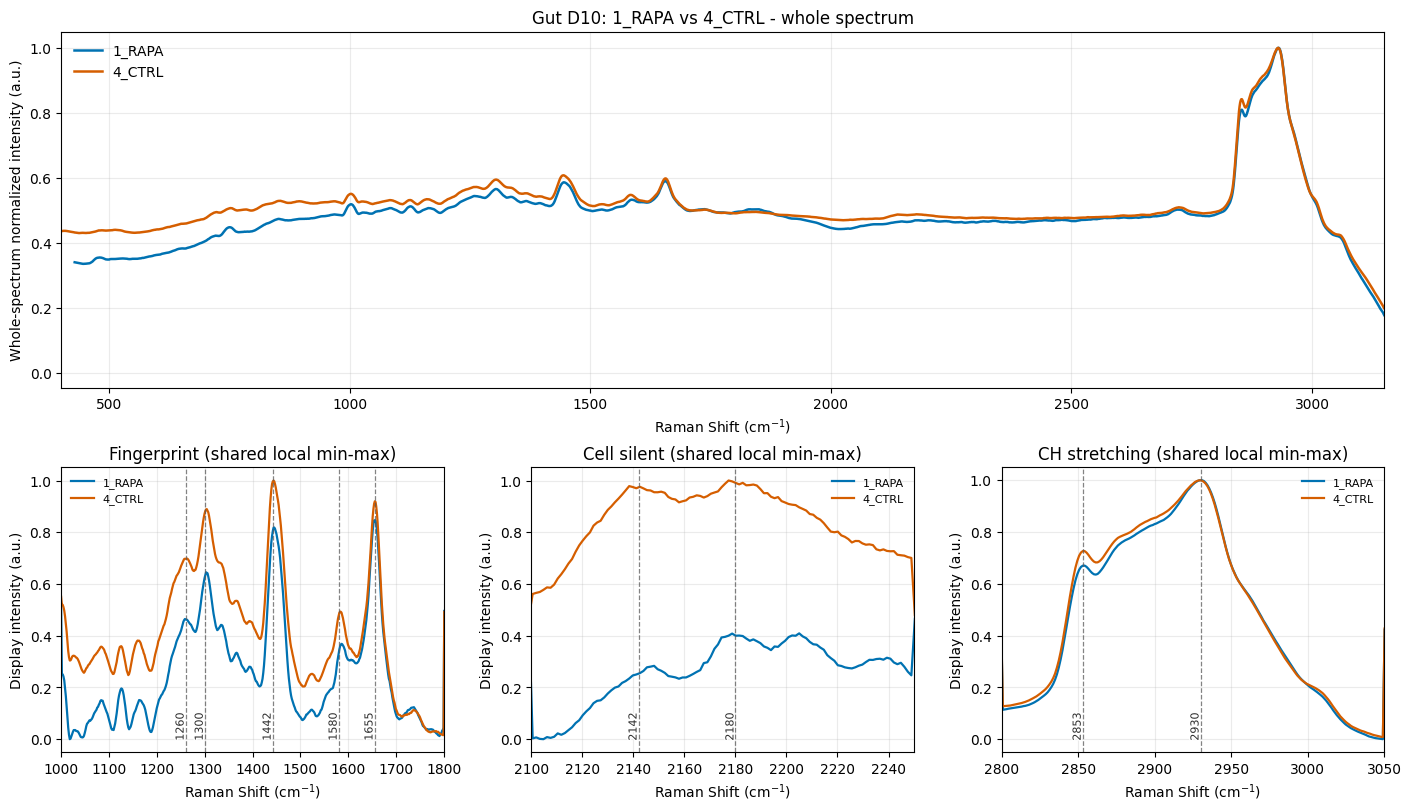

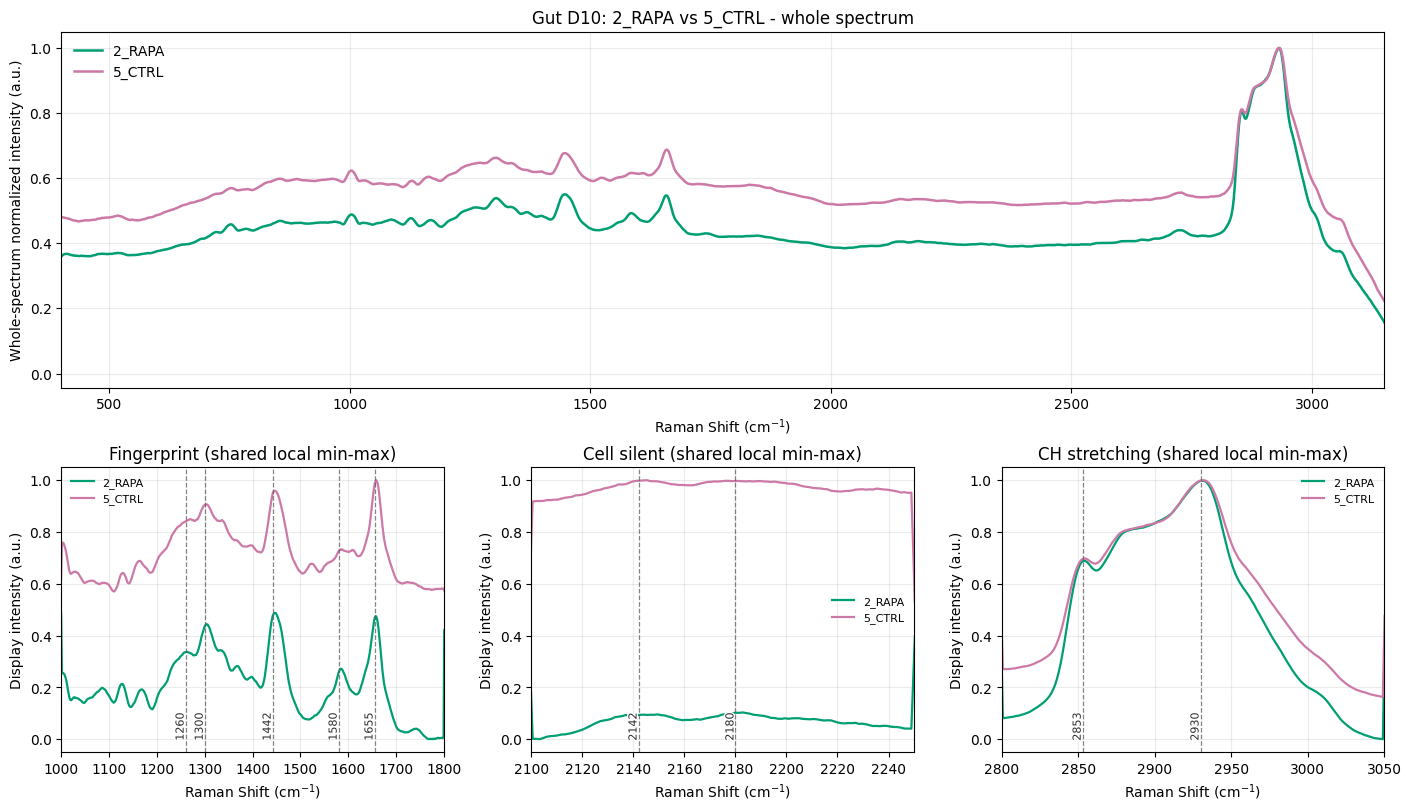

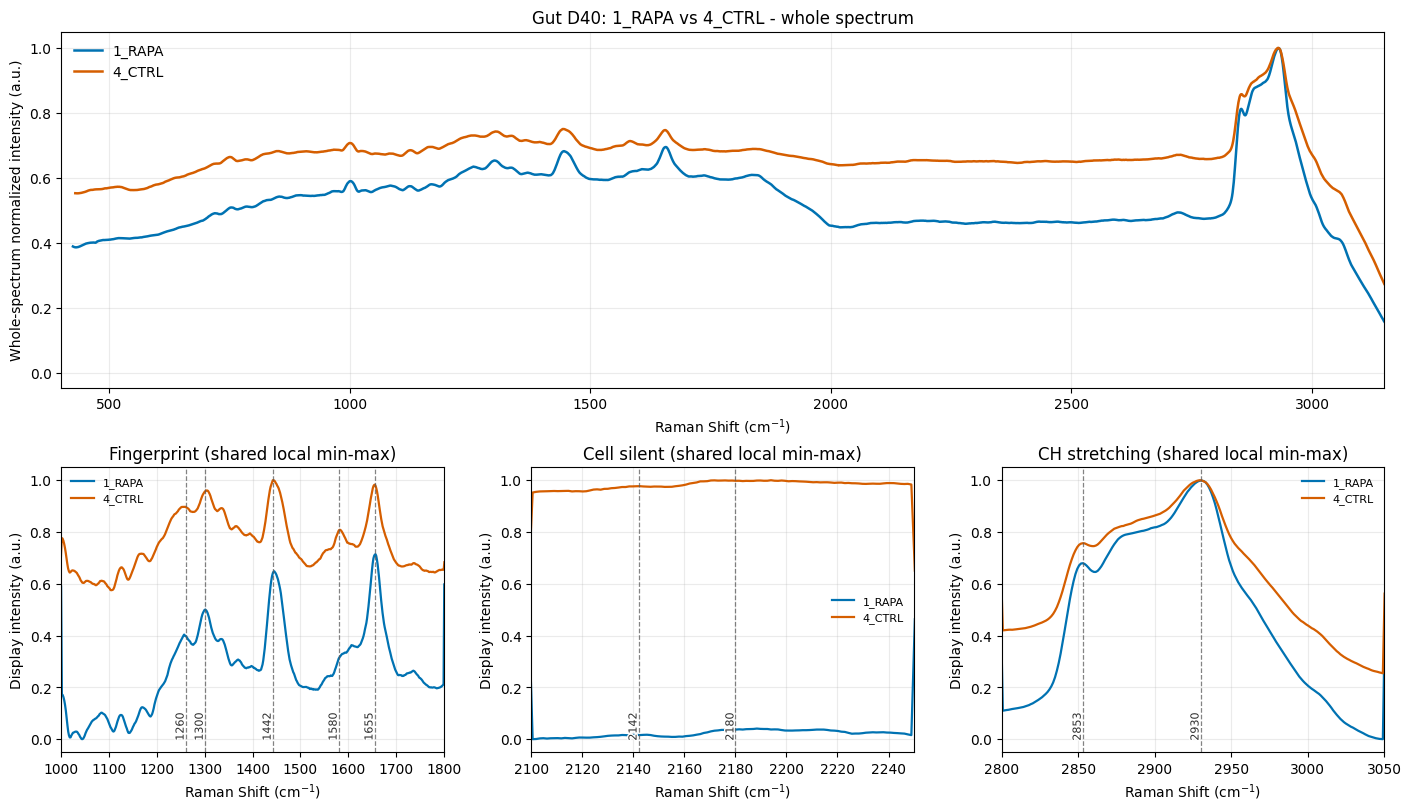

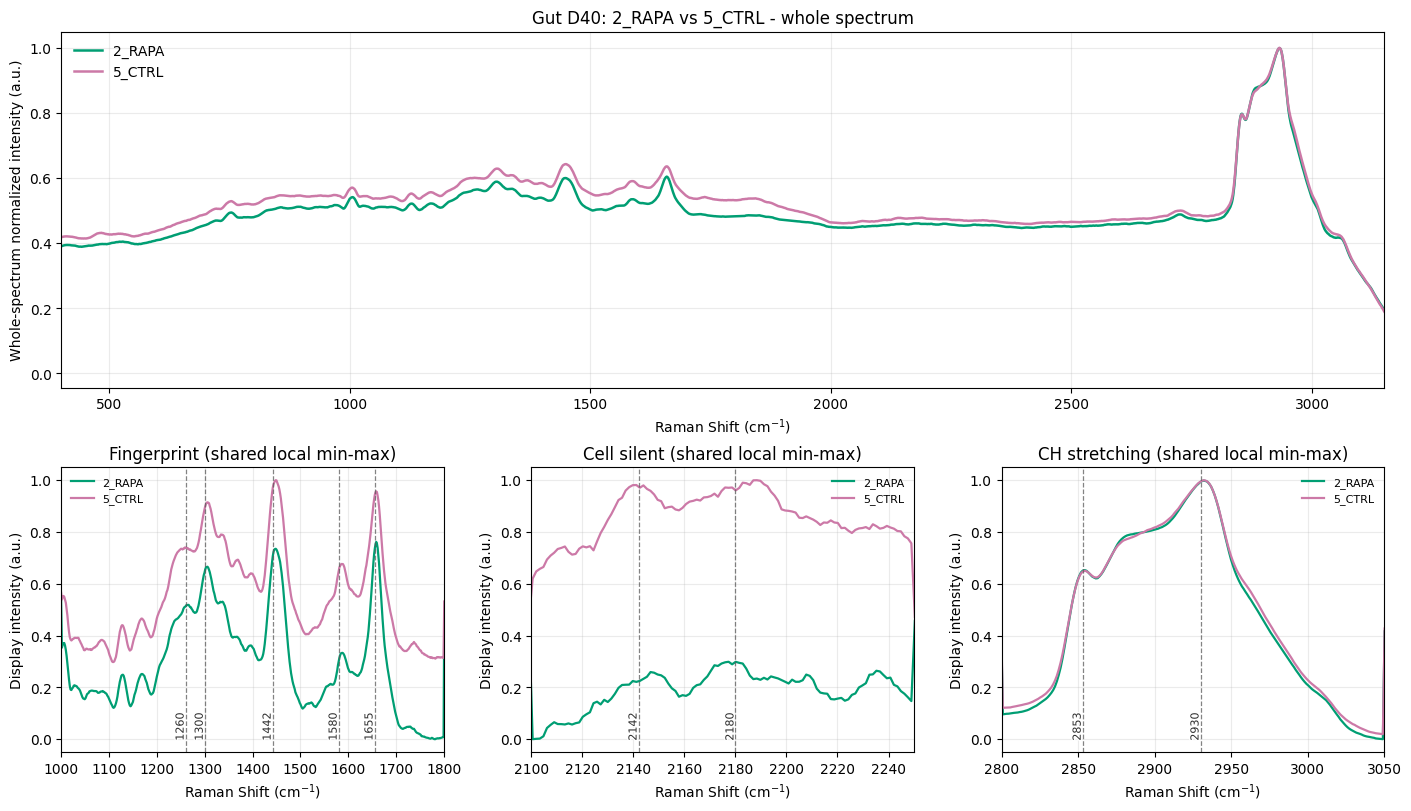

In [123]:
# Organ-specific merged spectra workflow
# Change this list if you only want one day, e.g. analysis_days = ["D10"]
analysis_days = sorted(organ_file_table['day'].unique())
organ_groups = ["1_RAPA", "2_RAPA", "4_CTRL", "5_CTRL"]
comparison_pairs = [("1_RAPA", "4_CTRL"), ("2_RAPA", "5_CTRL")]

# Savitzky-Golay smoothing settings
savgol_window = 21
savgol_polyorder = 3

# Plot ranges
background_subtraction_region = (400, 4000)
whole_spectrum_region = (400, 3150)
zoom_regions = {
    "Fingerprint": (1000, 1800),
    "Cell silent": (2100, 2250),
    "CH stretching": (2800, 3050),
}

# Edit these values to mark different peaks on the zoom subplots.
peak_markers = {
    "Fingerprint": [1260, 1300, 1442, 1580, 1655],
    "Cell silent": [2142, 2180],
    "CH stretching": [2853, 2930],
}

import matplotlib.patheffects as path_effects

group_colors = {
    "1_RAPA": "#0072B2",
    "2_RAPA": "#009E73",
    "4_CTRL": "#D55E00",
    "5_CTRL": "#CC79A7",
}


def clean_spectrum(wn, intensity):
    wn = np.asarray(wn, dtype=float)
    intensity = np.asarray(intensity, dtype=float)

    valid = np.isfinite(wn) & np.isfinite(intensity)
    wn = wn[valid]
    intensity = intensity[valid]

    order = np.argsort(wn)
    wn = wn[order]
    intensity = intensity[order]

    unique_wn, unique_indices = np.unique(wn, return_index=True)
    return unique_wn, intensity[unique_indices]


def merge_group_spectra(group_files):
    # Sum all raw spectra and their measured backgrounds onto the shared overlap.
    if group_files.empty:
        raise ValueError("No spectra found for this group.")

    sample_spectra = []
    background_spectra = []
    for _, row in group_files.iterrows():
        sample_wn, sample_intensity = sl.read_spectrum(Path.Path(row['spectrum_path']))
        bg_wn, bg_intensity = sl.read_spectrum(Path.Path(row['background_path']))
        sample_spectra.append(clean_spectrum(sample_wn, sample_intensity))
        background_spectra.append(clean_spectrum(bg_wn, bg_intensity))

    all_axes = [wn for wn, _ in sample_spectra + background_spectra]
    common_start = max(wn[0] for wn in all_axes)
    common_end = min(wn[-1] for wn in all_axes)
    if common_start >= common_end:
        raise ValueError("Spectra/backgrounds in this group do not have an overlapping wavenumber range.")

    reference_wn = sample_spectra[0][0]
    reference_wn = reference_wn[(reference_wn >= common_start) & (reference_wn <= common_end)]

    sample_intensities = []
    background_intensities = []
    for wn, intensity in sample_spectra:
        sample_intensities.append(np.interp(reference_wn, wn, intensity))
    for wn, intensity in background_spectra:
        background_intensities.append(np.interp(reference_wn, wn, intensity))

    total_intensity = np.sum(np.vstack(sample_intensities), axis=0)
    total_background = np.sum(np.vstack(background_intensities), axis=0)
    return reference_wn, total_intensity, total_background, len(sample_intensities)


def min_max_normalize(intensity):
    intensity = np.asarray(intensity, dtype=float)
    intensity_min = np.nanmin(intensity)
    intensity_max = np.nanmax(intensity)
    if np.isclose(intensity_max, intensity_min):
        return np.zeros_like(intensity)
    return (intensity - intensity_min) / (intensity_max - intensity_min)


def preprocess_merged_spectrum(wn, total_intensity, total_background):
    region_mask = (wn >= background_subtraction_region[0]) & (wn <= background_subtraction_region[1])
    if not np.any(region_mask):
        raise ValueError("Background subtraction range does not overlap this merged spectrum.")

    wn_region = wn[region_mask]
    intensity_region = total_intensity[region_mask]
    background_region = total_background[region_mask]

    sub_wn, bg_subtracted = prep.spectra_bg_subtraction(
        wn_region,
        intensity_region,
        wn_region,
        background_region,
    )

    normalized = min_max_normalize(bg_subtracted)
    smooth_wn, smoothed = prep.smoothing(
        sub_wn,
        normalized,
        window_length=savgol_window,
        polyorder=savgol_polyorder,
    )

    return {
        "wn": smooth_wn,
        "intensity": smoothed,
        "normalized_intensity": normalized,
        "bg_subtracted_intensity": bg_subtracted,
        "background_intensity": background_region,
    }


def shared_min_max_for_plot(spectra, xlim):
    # Local display-only scaling using one shared min/max across all plotted groups.
    region_values = []
    for spectrum in spectra:
        wn = spectrum["wn"]
        intensity = spectrum["intensity"]
        region_mask = (wn >= xlim[0]) & (wn <= xlim[1])
        if np.any(region_mask):
            region_values.append(intensity[region_mask])

    if not region_values:
        return [spectrum["intensity"] for spectrum in spectra]

    combined_values = np.concatenate(region_values)
    region_min = np.nanmin(combined_values)
    region_max = np.nanmax(combined_values)

    scaled_intensities = []
    for spectrum in spectra:
        wn = spectrum["wn"]
        y_plot = np.asarray(spectrum["intensity"], dtype=float).copy()
        region_mask = (wn >= xlim[0]) & (wn <= xlim[1])
        if np.any(region_mask):
            if np.isclose(region_max, region_min):
                y_plot[region_mask] = 0
            else:
                y_plot[region_mask] = (y_plot[region_mask] - region_min) / (region_max - region_min)
        scaled_intensities.append(y_plot)

    return scaled_intensities


def add_peak_markers(ax, peaks, xlim):
    peaks_in_range = [peak for peak in peaks if xlim[0] <= peak <= xlim[1]]
    if not peaks_in_range:
        return

    ymin, ymax = ax.get_ylim()
    label_y = ymin + 0.04 * (ymax - ymin)
    for peak in peaks_in_range:
        ax.axvline(peak, color="0.35", linestyle="--", linewidth=0.9, alpha=0.75)
        label = ax.text(
            peak,
            label_y,
            f"{peak:g}",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=8,
            color="0.18",
        )
        label.set_path_effects([
            path_effects.Stroke(linewidth=2.0, foreground="white"),
            path_effects.Normal(),
        ])


def plot_organ_pair(day, group_a, group_b):
    fig = plt.figure(figsize=(14, 8), constrained_layout=True)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.25, 1])
    full_ax = fig.add_subplot(gs[0, :])
    zoom_axes = [fig.add_subplot(gs[1, idx]) for idx in range(3)]

    for group in (group_a, group_b):
        spectrum = organ_processed_spectra[(day, group)]
        full_ax.plot(
            spectrum["wn"],
            spectrum["intensity"],
            label=group,
            color=group_colors[group],
            linewidth=1.8,
        )

    full_ax.set_title(f"{target_organ} {day}: {group_a} vs {group_b} - whole spectrum")
    full_ax.set_xlim(*whole_spectrum_region)
    full_ax.set_xlabel("Raman Shift (cm$^{-1}$)")
    full_ax.set_ylabel("Whole-spectrum normalized intensity (a.u.)")
    full_ax.grid(alpha=0.25)
    full_ax.legend(frameon=False)

    local_scaled_regions = {"Fingerprint", "Cell silent", "CH stretching"}

    for ax, (region_name, xlim) in zip(zoom_axes, zoom_regions.items()):
        use_local_scale = region_name in local_scaled_regions
        groups_to_plot = (group_a, group_b)
        spectra_to_plot = [organ_processed_spectra[(day, group)] for group in groups_to_plot]
        y_values_to_plot = (
            shared_min_max_for_plot(spectra_to_plot, xlim)
            if use_local_scale
            else [spectrum["intensity"] for spectrum in spectra_to_plot]
        )

        for group, spectrum, y_plot in zip(groups_to_plot, spectra_to_plot, y_values_to_plot):
            ax.plot(
                spectrum["wn"],
                y_plot,
                label=group,
                color=group_colors[group],
                linewidth=1.6,
            )
        scale_note = "shared local min-max" if use_local_scale else "whole-spectrum scale"
        ax.set_title(f"{region_name} ({scale_note})")
        ax.set_xlim(*xlim)
        ax.set_xlabel("Raman Shift (cm$^{-1}$)")
        ax.set_ylabel("Display intensity (a.u.)" if use_local_scale else "Normalized intensity (a.u.)")
        ax.grid(alpha=0.25)
        add_peak_markers(ax, peak_markers.get(region_name, []), xlim)
        ax.legend(frameon=False, fontsize=8)

    return fig


organ_merged_raw = {}
organ_processed_spectra = {}
summary_rows = []

for day in analysis_days:
    day_table = organ_file_table[organ_file_table['day'].eq(day)]

    for group in organ_groups:
        group_files = day_table[day_table['group'].eq(group)]
        if group_files.empty:
            print(f"Skipping {target_organ} {day} {group}: no files found")
            continue

        wn, total_intensity, total_background, n_spectra = merge_group_spectra(group_files)
        organ_merged_raw[(day, group)] = {
            "wn": wn,
            "total_intensity": total_intensity,
            "total_background": total_background,
            "n_spectra": n_spectra,
        }
        organ_processed_spectra[(day, group)] = preprocess_merged_spectrum(wn, total_intensity, total_background)
        summary_rows.append({"day": day, "group": group, "merged_spectra": n_spectra})

organ_summary = pd.DataFrame(summary_rows)
try:
    display(organ_summary)
except NameError:
    print(organ_summary)

for day in analysis_days:
    for group_a, group_b in comparison_pairs:
        if (day, group_a) in organ_processed_spectra and (day, group_b) in organ_processed_spectra:
            plot_organ_pair(day, group_a, group_b)
            plt.show()
        else:
            print(f"Skipping {target_organ} {day} {group_a} vs {group_b}: one or both spectra are missing")


### Gut Ratiometric Analysis

This cell analyzes each individual Gut spectrum with its paired measured background, applies baseline correction from `2300-2600 cm^-1`, computes peak ratios against `2930 cm^-1`, saves the ratio table, performs Student t-tests, saves statistics, and plots treatment/control bar plots.

Saved ratiometric data to D:\Chrome\Workspace\Labs\Shi\spontaneous\gut_ratiomatric.csv
Saved statistics to D:\Chrome\Workspace\Labs\Shi\spontaneous\gut_statistics.csv
Saved bar plot to D:\Chrome\Workspace\Labs\Shi\spontaneous\gut_ratiomatric_barplot.png


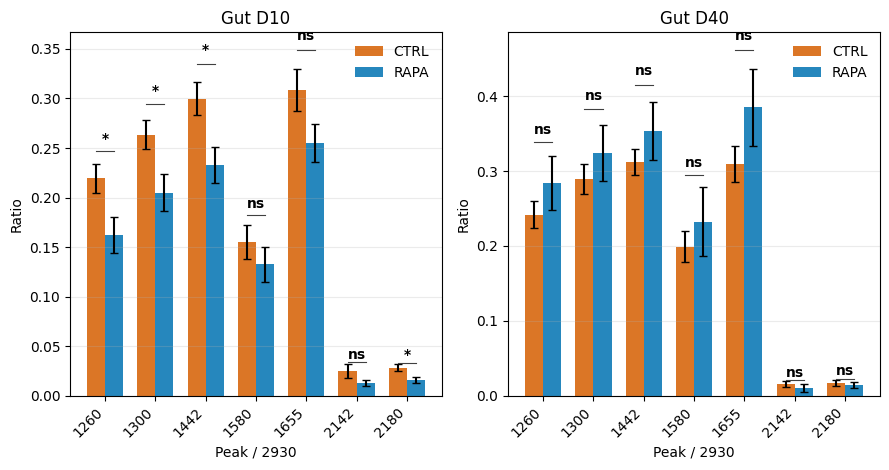

,organ,day,group,treatment,sample_name,baseline_2300_2600,denominator_2930,1260,1300,1442,1580,1655,2142,2180
0,Gut,D10,1_RAPA,RAPA,RAPA_D10_RAPA_1,910.789689,4457.802311,0.171811,0.197852,0.217888,0.083321,0.245544,0.017821,0.024376
1,Gut,D10,1_RAPA,RAPA,RAPA_D10_RAPA_2,1281.935272,3612.146728,0.209473,0.249512,0.270955,0.146039,0.275448,0.013656,0.023221
2,Gut,D10,1_RAPA,RAPA,RAPA_D10_RAPA_3,2437.552487,3415.827513,0.101477,0.133169,0.134154,0.061820,0.161304,0.000000,0.000000
3,Gut,D10,1_RAPA,RAPA,RAPA_D10_RAPA_4,3550.435180,5394.932820,0.226737,0.287692,0.313989,0.212466,0.324798,0.000000,0.018991
4,Gut,D10,1_RAPA,RAPA,RAPA_D10_RAPA_5,4024.781298,2388.748702,0.140691,0.187254,0.221391,0.151401,0.396790,0.000000,0.000000


,organ,day,peak,denominator_peak,ctrl_n,rapa_n,ctrl_mean,rapa_mean,ctrl_sem,rapa_sem,t_statistic,p_value,significance
0,Gut,D10,1260,2930,13,13,0.219381,0.162415,0.014485,0.018239,-2.445822,0.022585,*
1,Gut,D10,1300,2930,13,13,0.263583,0.204902,0.015025,0.018747,-2.442501,0.022717,*
2,Gut,D10,1442,2930,13,13,0.299612,0.232994,0.016759,0.018395,-2.677111,0.013235,*
3,Gut,D10,1580,2930,13,13,0.155469,0.132650,0.017073,0.017286,-0.939208,0.356982,ns
4,Gut,D10,1655,2930,13,13,0.308836,0.255505,0.021170,0.019105,-1.870164,0.073836,ns
5,Gut,D10,2142,2930,13,13,0.025225,0.012687,0.006762,0.003126,-1.683098,0.110731,ns
6,Gut,D10,2180,2930,13,13,0.028274,0.015917,0.003403,0.003354,-2.586033,0.016209,*
7,Gut,D40,1260,2930,13,13,0.241677,0.283726,0.017843,0.036053,1.045320,0.310064,ns
8,Gut,D40,1300,2930,13,13,0.289225,0.324153,0.020396,0.037774,0.813612,0.426244,ns
9,Gut,D40,1442,2930,13,13,0.312048,0.353505,0.017980,0.038630,0.972962,0.344240,ns


In [124]:
# Gut ratiometric analysis
from scipy.stats import ttest_ind

ratio_denominator_peak = 2930
baseline_region = (2300, 2600)
ratiometric_output_path = Path.Path(f"{target_organ.lower()}_ratiomatric.csv")
statistics_output_path = Path.Path(f"{target_organ.lower()}_statistics.csv")
barplot_output_path = Path.Path(f"{target_organ.lower()}_ratiomatric_barplot.png")

# Use fingerprint and cell-silent markers for ratio comparisons.
# CH stretching markers are not compared; 2930 is used only as the denominator.
ratiometric_regions = ["Fingerprint", "Cell silent"]
interesting_peaks = sorted({peak for region in ratiometric_regions for peak in peak_markers.get(region, [])})
ratio_peaks = [peak for peak in interesting_peaks if not np.isclose(peak, ratio_denominator_peak)]


def subtract_measured_background(row):
    sample_wn, sample_intensity = sl.read_spectrum(Path.Path(row['spectrum_path']))
    bg_wn, bg_intensity = sl.read_spectrum(Path.Path(row['background_path']))
    sub_wn, sub_intensity = prep.spectra_bg_subtraction(
        sample_wn,
        sample_intensity,
        bg_wn,
        bg_intensity,
    )
    order = np.argsort(sub_wn)
    return np.asarray(sub_wn, dtype=float)[order], np.asarray(sub_intensity, dtype=float)[order]


def baseline_correct_from_region(wn, intensity, region=baseline_region):
    baseline_mask = (wn >= region[0]) & (wn <= region[1])
    if not np.any(baseline_mask):
        raise ValueError(f"No points found in baseline region {region}.")

    baseline = np.nanmean(intensity[baseline_mask])
    corrected = np.asarray(intensity, dtype=float) - baseline
    corrected[corrected < 0] = 0
    return corrected, baseline


def intensity_at_peak(wn, intensity, peak):
    peak_idx = np.nanargmin(np.abs(wn - peak))
    return intensity[peak_idx]


def treatment_from_group(group):
    if 'RAPA' in group:
        return 'RAPA'
    if 'CTRL' in group:
        return 'CTRL'
    return group


def significance_label(p_value):
    if pd.isna(p_value):
        return 'n/a'
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return 'ns'


ratiometric_rows = []

for _, row in organ_file_table.iterrows():
    wn, bg_subtracted = subtract_measured_background(row)
    corrected, baseline = baseline_correct_from_region(wn, bg_subtracted)
    denominator = intensity_at_peak(wn, corrected, ratio_denominator_peak)

    ratio_row = {
        'organ': row['organ'],
        'day': row['day'],
        'group': row['group'],
        'treatment': treatment_from_group(row['group']),
        'sample_name': row['filename'],
        'baseline_2300_2600': baseline,
        'denominator_2930': denominator,
    }

    for peak in ratio_peaks:
        ratio_row[str(peak)] = (
            intensity_at_peak(wn, corrected, peak) / denominator
            if not np.isclose(denominator, 0)
            else np.nan
        )

    ratiometric_rows.append(ratio_row)

ratiometric_df = pd.DataFrame(ratiometric_rows)
ratiometric_df.to_csv(ratiometric_output_path, index=False)
print(f"Saved ratiometric data to {ratiometric_output_path.resolve()}")

statistics_rows = []
for day in sorted(ratiometric_df['day'].dropna().unique()):
    day_df = ratiometric_df[ratiometric_df['day'].eq(day)]
    ctrl_df = day_df[day_df['treatment'].eq('CTRL')]
    rapa_df = day_df[day_df['treatment'].eq('RAPA')]

    for peak in ratio_peaks:
        peak_col = str(peak)
        ctrl_values = ctrl_df[peak_col].dropna().to_numpy(dtype=float)
        rapa_values = rapa_df[peak_col].dropna().to_numpy(dtype=float)

        if len(ctrl_values) >= 2 and len(rapa_values) >= 2:
            t_stat, p_value = ttest_ind(rapa_values, ctrl_values, equal_var=False)
        else:
            t_stat, p_value = np.nan, np.nan

        statistics_rows.append({
            'organ': target_organ,
            'day': day,
            'peak': peak,
            'denominator_peak': ratio_denominator_peak,
            'ctrl_n': len(ctrl_values),
            'rapa_n': len(rapa_values),
            'ctrl_mean': np.nanmean(ctrl_values) if len(ctrl_values) else np.nan,
            'rapa_mean': np.nanmean(rapa_values) if len(rapa_values) else np.nan,
            'ctrl_sem': np.nanstd(ctrl_values, ddof=1) / np.sqrt(len(ctrl_values)) if len(ctrl_values) > 1 else np.nan,
            'rapa_sem': np.nanstd(rapa_values, ddof=1) / np.sqrt(len(rapa_values)) if len(rapa_values) > 1 else np.nan,
            't_statistic': t_stat,
            'p_value': p_value,
            'significance': significance_label(p_value),
        })

statistics_df = pd.DataFrame(statistics_rows)
statistics_df.to_csv(statistics_output_path, index=False)
print(f"Saved statistics to {statistics_output_path.resolve()}")

# Bar plot: one subplot per day, CTRL vs RAPA for each ratio peak.
days = sorted(ratiometric_df['day'].dropna().unique())
fig, axes = plt.subplots(1, len(days), figsize=(max(7, 4.5 * len(days)), 4.8), sharey=False)
if len(days) == 1:
    axes = [axes]

x = np.arange(len(ratio_peaks))
bar_width = 0.36

for ax, day in zip(axes, days):
    day_stats = statistics_df[statistics_df['day'].eq(day)].set_index('peak').reindex(ratio_peaks)

    ctrl_means = day_stats['ctrl_mean'].to_numpy(dtype=float)
    rapa_means = day_stats['rapa_mean'].to_numpy(dtype=float)
    ctrl_sems = day_stats['ctrl_sem'].to_numpy(dtype=float)
    rapa_sems = day_stats['rapa_sem'].to_numpy(dtype=float)

    ax.bar(x - bar_width / 2, ctrl_means, width=bar_width, yerr=ctrl_sems, capsize=3, label='CTRL', color='#D55E00', alpha=0.85)
    ax.bar(x + bar_width / 2, rapa_means, width=bar_width, yerr=rapa_sems, capsize=3, label='RAPA', color='#0072B2', alpha=0.85)

    for idx, peak in enumerate(ratio_peaks):
        p_value = day_stats.loc[peak, 'p_value']
        label = day_stats.loc[peak, 'significance']
        if pd.notna(p_value):
            y_base = np.nanmax([
                ctrl_means[idx] + (ctrl_sems[idx] if pd.notna(ctrl_sems[idx]) else 0),
                rapa_means[idx] + (rapa_sems[idx] if pd.notna(rapa_sems[idx]) else 0),
            ])
            if pd.notna(y_base):
                y_text = y_base * 1.08 if y_base > 0 else y_base + 0.03
                ax.plot(
                    [idx - bar_width / 2, idx + bar_width / 2],
                    [y_text * 0.98, y_text * 0.98],
                    color='0.25',
                    linewidth=0.8,
                )
                ax.text(idx, y_text, label, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(f"{target_organ} {day}")
    ax.set_xticks(x)
    ax.set_xticklabels([str(peak) for peak in ratio_peaks], rotation=45, ha='right')
    ax.set_xlabel(f"Peak / {ratio_denominator_peak}")
    ax.set_ylabel("Ratio")
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False)

plt.tight_layout()
fig.savefig(barplot_output_path, dpi=300, bbox_inches='tight')
print(f"Saved bar plot to {barplot_output_path.resolve()}")
plt.show()

try:
    display(ratiometric_df.head())
    display(statistics_df)
except NameError:
    print(ratiometric_df.head().to_string(index=False))
    print(statistics_df.to_string(index=False))